In [ ]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns 

from datetime import datetime 

from scipy import stats 





from IPython.display import display_html

sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (10, 6)


# Walmart Sales Analysis 📊

## Project Overview
This project explores Walmart sales data to uncover trends in weekly sales, seasonality patterns, and store performance.
The goal is to generate actionable insights using Python for data cleaning, analysis, and visualization.

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset Source:** Kaggle – Walmart Sales Dataset


In [ ]:
pd.read_csv("../data/walmart_sales.csv")

## Dataset Overview
The dataset contains historical sales data from multiple Walmart stores, including weekly sales, dates, and additional economic indicators.


In [3]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.shape
print(f'The dataset contains {df.shape[0]} rows and {df.shape[1]} columns')

The dataset contains 6435 rows and 8 columns


## Data Cleaning
In this section, the dataset is cleaned to ensure accuracy and consistency.
Steps include handling date formats, checking for missing values, and standardizing column names.


In [6]:
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [7]:
duplicate_values=df.duplicated().sum()
print(f'The data contains {duplicate_values} duplicate values')

The data contains 0 duplicate values


In [8]:
df.describe().style.background_gradient(cmap='bone_r')

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1046964.877562,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,564366.622054,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,209986.250000,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,553350.105000,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,960746.040000,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1420158.660000,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3818686.450000,1.000000,100.140000,4.468000,227.232807,14.313000


In [9]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")


In [10]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")


In [11]:
df["Date"].head(10)


0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
5   2010-03-12
6   2010-03-19
7   2010-03-26
8   2010-04-02
9   2010-04-09
Name: Date, dtype: datetime64[ns]

## Feature Engineering
New features such as year, month, and season were extracted from the date column to support time-based analysis.


In [12]:
def date_to_season(date):
    if pd.isna(date):
        return None

    month = date.month
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["Date"].apply(date_to_season)


In [13]:
df[["Date", "season"]].head(10)


,Date,season
0,2010-02-05,Winter
1,2010-02-12,Winter
2,2010-02-19,Winter
3,2010-02-26,Winter
4,2010-03-05,Spring
5,2010-03-12,Spring
6,2010-03-19,Spring
7,2010-03-26,Spring
8,2010-04-02,Spring
9,2010-04-09,Spring


In [14]:
# Extract year from the 'date' column
df['year'] = df['Date'].dt.year

# Extract month from the 'date' column
df['month'] = df['Date'].dt.month

# Extract month name from the 'date' column
df['month_name'] = df['Date'].dt.month_name()

# Extract day from the 'date' column
df['day'] = df['Date'].dt.day

# Extract day of the week (0 = Monday, 1 = Tuesday, ..., 6 = Sunday) from the 'date' column
df['day_of_week'] = df['Date'].dt.dayofweek

df.sample(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,season,year,month,month_name,day,day_of_week
4102,29,2011-12-23,1016637.39,0,39.83,3.413,136.588387,9.357,Winter,2011,12,December,23,4
1881,14,2010-07-09,2236209.13,0,82.45,2.793,182.256960,8.743,Summer,2010,7,July,9,4
6005,42,2012-10-26,514756.08,0,70.50,4.301,131.193097,6.943,Autumn,2012,10,October,26,4
3285,23,2012-10-05,1464616.59,0,56.65,4.027,138.825600,4.145,Autumn,2012,10,October,5,4
2249,16,2012-02-03,475905.10,0,25.53,3.031,196.872892,6.162,Winter,2012,2,February,3,4


# Exploratory Data Analysis (EDA)
Distribution Analysis of Key Walmart Sales and Economic Indicators

This analyzes the distribution of weekly sales and key economic indicators to reveal patterns such as sales spikes, economic stability, and shifts in market conditions that may impact consumer behavior.

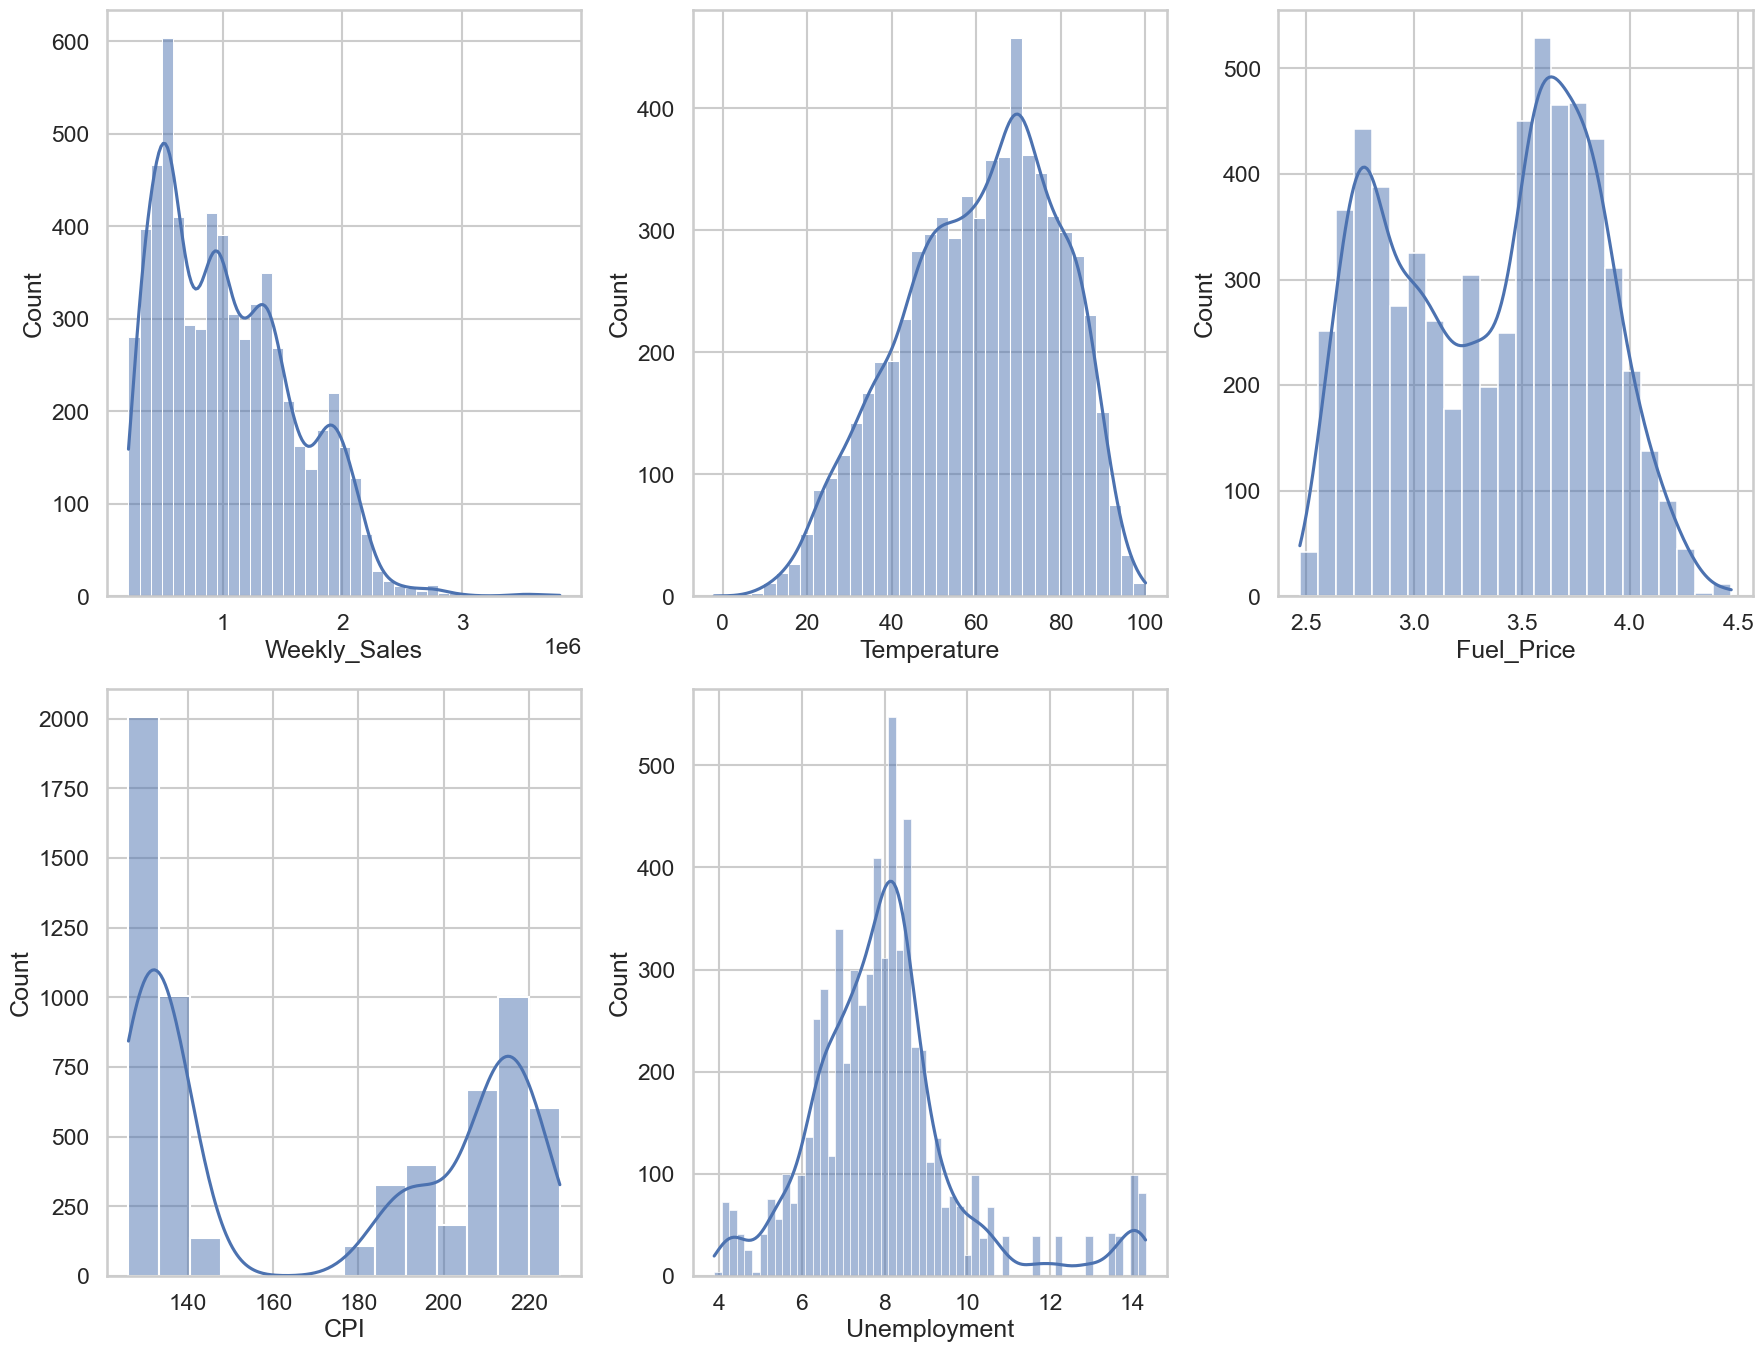

In [15]:
features = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

plt.figure(figsize=(18, 20))

for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    
    sns.histplot(data=df, x=col, kde=True)

plt.tight_layout()
plt.show()


Weekly Sales

The histogram of weekly sales indicates a right-skewed distribution, suggesting that there are relatively fewer instances of very high sales compared to lower sales amounts. This could indicate occasional spikes in sales or a few high-performing periods.

Temperature and Unemployment

The histograms of temperature and unemployment show approximately normal distributions, indicating that the majority of the data points are centered around the mean with relatively few outliers. This suggests that these factors may follow typical patterns without significant deviations.

Fuel Price and CPI

The histograms of fuel price and CPI exhibit bimodal distributions, suggesting the presence of two distinct peaks or modes in the data. This could imply the existence of different market conditions or states within the dataset, potentially indicating varying economic situations or consumer behaviors.


# Correlation Analysis Between Weekly Sales and Economic Factors
This explores the strength and direction of relationships between weekly sales and economic indicators, showing mostly weak correlations with a notable inverse relationship between CPI and unemployment.

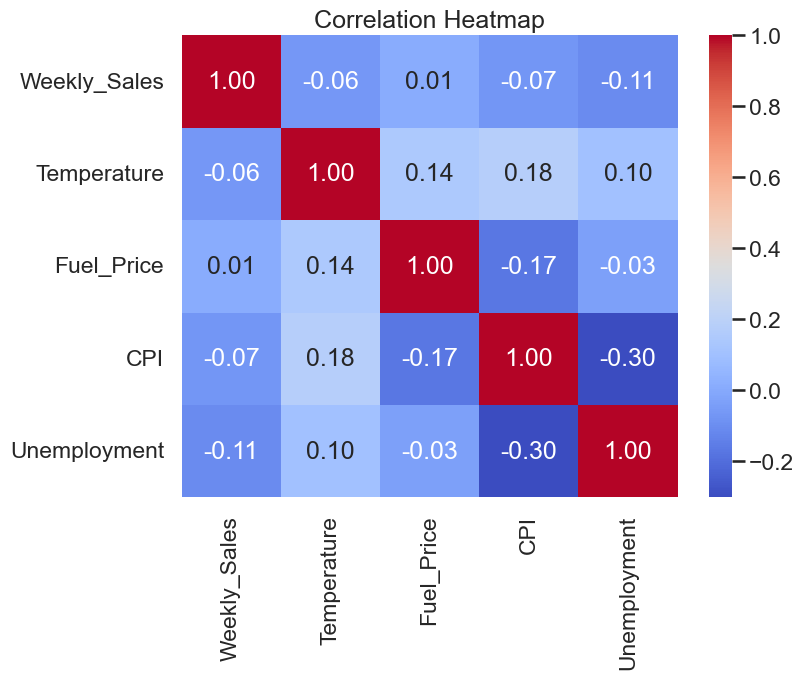

In [16]:
correlation_matrix = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Weekly sales slightly decrease with higher temperature, fuel price, and unemployment, but rise with CPI; temperature rises slightly with fuel price, CPI, and unemployment; fuel price drops slightly as CPI rises; CPI moderately drops as unemployment rises.

# Seasonal and Yearly Sales Trends (Pivot Table)

In [17]:
pd.pivot_table(data = df,
              index = 'year',
              columns = 'season',
              values = 'Weekly_Sales',
              aggfunc = 'sum')

season,Autumn,Spring,Summer,Winter
year,,,,
2010,5.972831e+08,6.000431e+08,6.124664e+08,4.790935e+08
2011,6.142714e+08,5.875311e+08,6.082841e+08,6.381134e+08
2012,3.650072e+08,6.091970e+08,6.649705e+08,3.609581e+08



Summer and Spring consistently record the highest total sales, suggesting stronger consumer activity during warmer seasons.

Winter sales show more variability, with noticeably lower totals in 2010 and 2012 compared to 2011.

2011 stands out as the strongest overall sales year.


# Distribution of Weekly Sales
This visualization shows how weekly sales are distributed across all seasons.


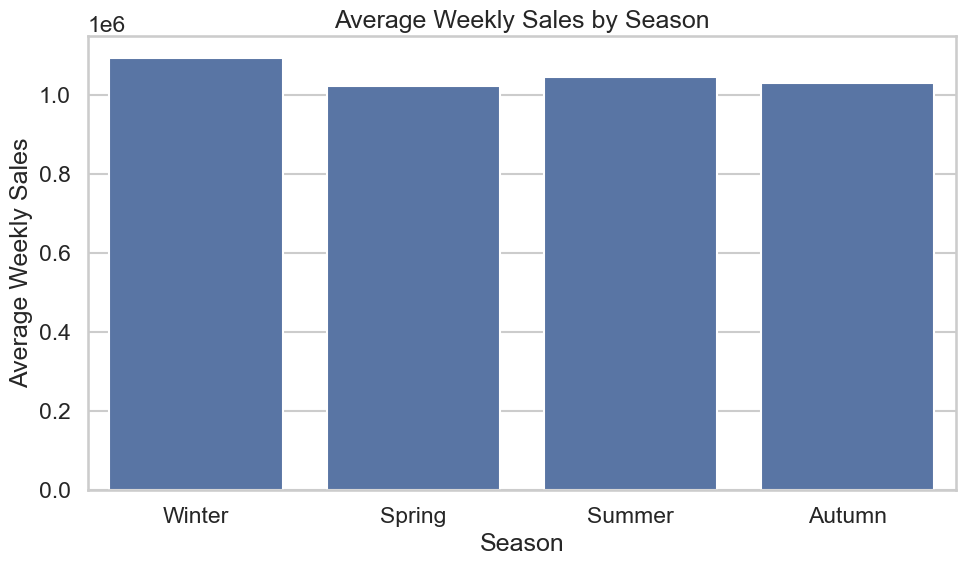

In [18]:
season_sales = (
    df.groupby("season")["Weekly_Sales"]
    .mean()
    .reindex(["Winter", "Spring", "Summer", "Autumn"])
)

plt.figure()
sns.barplot(
    x=season_sales.index,
    y=season_sales.values
)
plt.title("Average Weekly Sales by Season")
plt.xlabel("Season")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()


Average weekly sales tend to be higher during winter, likely driven by holiday shopping and end-of-year promotions.

# Distribution of Holiday Weeks Across Years
This illustrates the distribution of holiday weeks across different years within the dataset. 

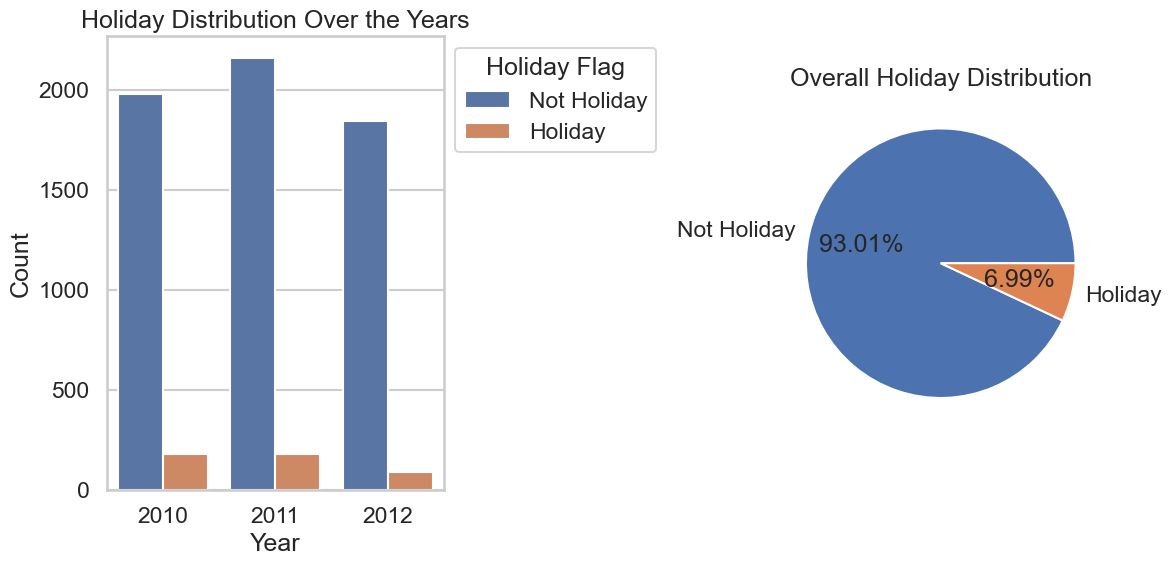

In [19]:
# Group by year and holiday_flag to get counts
holiday_counts = df.groupby(['year', 'Holiday_Flag']).size().unstack(fill_value=0).reset_index()

# Melt DataFrame to long format
holiday_counts_melted = pd.melt(holiday_counts, id_vars='year', var_name='Holiday Flag', value_name='Count')

# Plot using Seaborn
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Bar plot
sns.barplot(data=holiday_counts_melted, x='year', y='Count', hue='Holiday Flag', ax=ax[0])
ax[0].set_title('Holiday Distribution Over the Years')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Count')

# Get legend handles
handles, _ = ax[0].get_legend_handles_labels()

ax[0].legend(handles=handles, labels=['Not Holiday', 'Holiday'], title='Holiday Flag', loc='upper left', bbox_to_anchor=(1, 1))

ax[1].pie(df['Holiday_Flag'].value_counts().values, labels=['Not Holiday', 'Holiday'], autopct='%1.2f%%')
ax[1].set_title('Overall Holiday Distribution')

plt.tight_layout()
plt.show()

The overall holiday percentage, calculated as 6.99%, indicates that holidays occur in a relatively small proportion of the observed data points.

# Distribution of Records Across Years
This shows how the dataset is distributed across different years. This will help assess whether the data is evenly balanced over time or dominated by specific years, which is important for ensuring fair trend and comparative analysis.

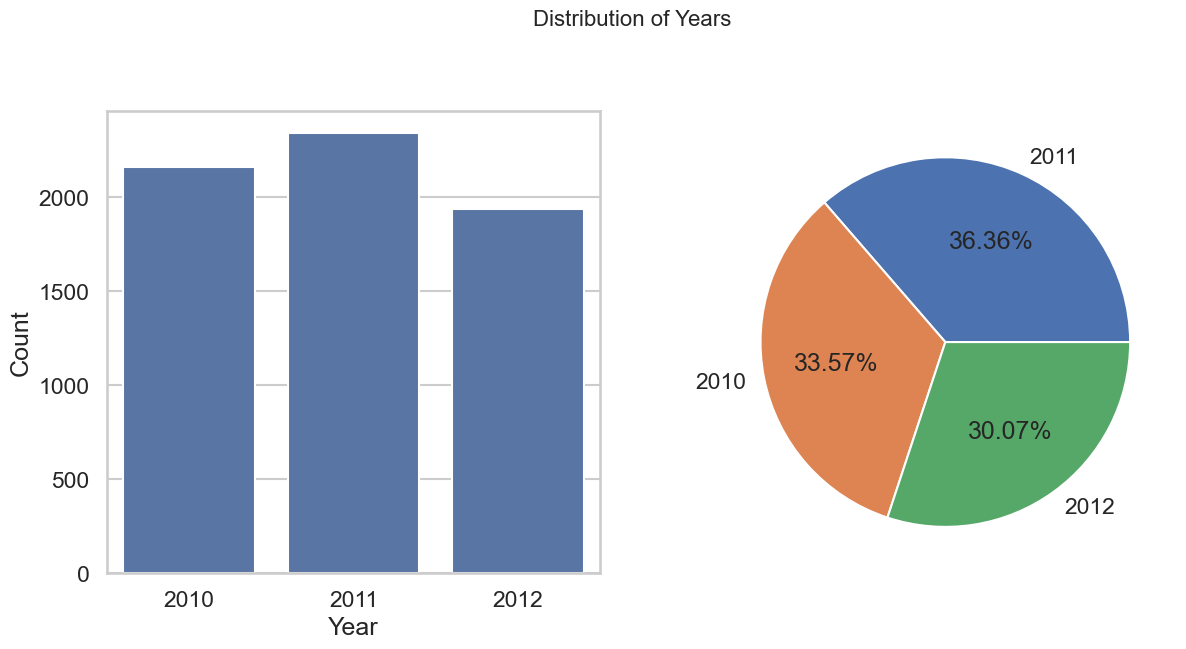

In [20]:
# Calculate the count of each year
year_counts = df['year'].value_counts()

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Countplot for the distribution of years
sns.countplot(data=df, x='year', ax=ax[0])
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Count')

# Pie chart for the distribution of years
ax[1].pie(year_counts.values, labels=year_counts.index, autopct='%1.2f%%')

# Set a single title for the entire figure
plt.suptitle('Distribution of Years', fontsize=16, y=1.05)

plt.show()

## Key Insights
- Weekly sales show clear seasonal patterns, with peaks during holiday periods.
- Temperature & Unemployment
Approximately normal: values cluster around the mean with few outliers.
- Fuel Price & CPI
Bimodal distribution has two peaks suggest differing economic conditions or consumer behaviors
- Certain stores consistently outperform others in terms of average weekly sales.
- Sales distribution is right-skewed, indicating occasional high-revenue weeks.

## Conclusion
This analysis highlights important trends in Walmart sales data, particularly seasonal demand and store-level performance.
These insights will help to support inventory planning and sales forecasting decisions.
